In [1]:
#load modules
from matplotlib import pyplot as plt
import numpy as np
from spectral1d import solve_nonlinear_problem # needed module
from overscreening_breakdown import overscreening_breakdown #needed module
from problems_for_updated_testing import \
problem_discontinuous_lhs_1, \
problem_discontinuous_lhs_2, \
problem_discontinuous_lhs_3, \
problem_discontinuous_lhs_4, \
problem_neumann_bc_at_0, \
problem_neumann_bc_at_0_der_4_and_2, \
problem_neumann_bc_at_0_der_4_and_2_2

%matplotlib inline

In [2]:
all_problems = [problem_discontinuous_lhs_1(), \
                problem_discontinuous_lhs_2(), \
                problem_discontinuous_lhs_3(), \
                problem_discontinuous_lhs_4(), \
                problem_neumann_bc_at_0(), \
                problem_neumann_bc_at_0_der_4_and_2(), \
                problem_neumann_bc_at_0_der_4_and_2_2()
               ]

# initial distribution to make things harder for the solver.
def some_func(x):
    return 1/(1+x)

for j in range(0,len(all_problems)):
    all_problems[j].set_parameters(initial_guess_solution=some_func)

In [3]:
N = 100
domain = [0,np.inf]
tolerance = 1.0e-10
use_method = "newton"
use_adjoint_opimization = False
use_globalization = False
L = 6 #on the sellection of this parameter, see bellow 

solver = solve_nonlinear_problem(N=N, 
                                 domain=domain, 
                                 tolerance=tolerance, 
                                 use_method=use_method, 
                                 use_adjoint_opimization = use_adjoint_opimization, 
                                 use_globalization = use_globalization)
solver.set_mapping_parameter(L)

In [4]:
def plot_all(c, problem):
    #plotting in computational domain in [0, $pi$]
    t = np.arange(0, np.pi, 0.01) 
    sol = solver.obtain_solution_in_basis(c, t)
    plt.title("solution on the mapped segment [0,$\pi$]")
    plt.plot(t, sol,'.')
    plt.legend([problem.info()])
    plt.show()

    #plotting in physical domain for 0<=x<=100
    x = np.arange(0, 10, 0.005)
    sol = solver.obtain_solution_in_domain(c, x)
    plt.title("solution on the part of the $\mathbb{R}^+$")
    plt.plot(x, sol, '.')
    plt.legend([problem.info()])
    plt.show()


    #plotting the rhs of the problem
    x = np.arange(0.0,10, 0.01)
    sol = solver.obtain_solution_in_domain(c, x)
    rhs = problem.right_hand_side(x,sol,0)
    plt.title("rhs on the part of the $\mathbb{R}^+$")
    plt.plot(x, rhs, '.')
    plt.legend([problem.info()])
    plt.show()    

newton: relative target tolerance = 1.009950e-09
newton: iteration  1 , residual norm 2.378074e-01 , weight = 1.000000e+00
newton: iteration  2 , residual norm 8.322658e-02 , weight = 1.000000e+00
newton: iteration  3 , residual norm 1.794890e-02 , weight = 5.000000e-01
newton: iteration  4 , residual norm 3.432262e-03 , weight = 5.000000e-01
newton: iteration  5 , residual norm 7.235371e-04 , weight = 5.000000e-01
newton: iteration  6 , residual norm 1.669143e-04 , weight = 5.000000e-01
newton: iteration  7 , residual norm 4.956531e-05 , weight = 5.000000e-01
newton: iteration  8 , residual norm 3.590264e-05 , weight = 1.000000e+00
newton: iteration  9 , residual norm 7.556800e-06 , weight = 5.000000e-01
newton: iteration  10 , residual norm 1.768897e-06 , weight = 5.000000e-01
newton: iteration  11 , residual norm 4.926322e-07 , weight = 5.000000e-01
newton: iteration  12 , residual norm 3.921072e-07 , weight = 1.000000e+00
newton: iteration  13 , residual norm 8.415268e-08 , weight 

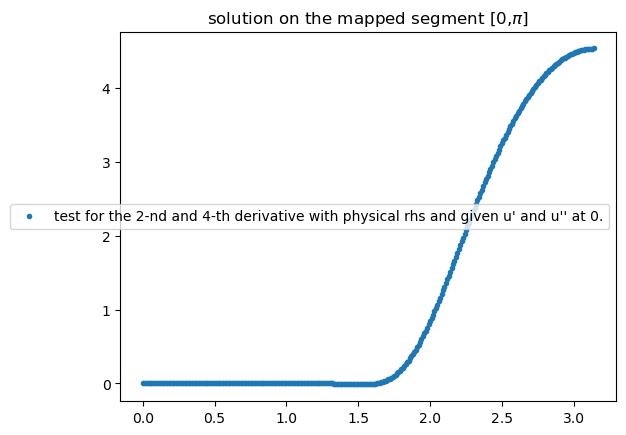

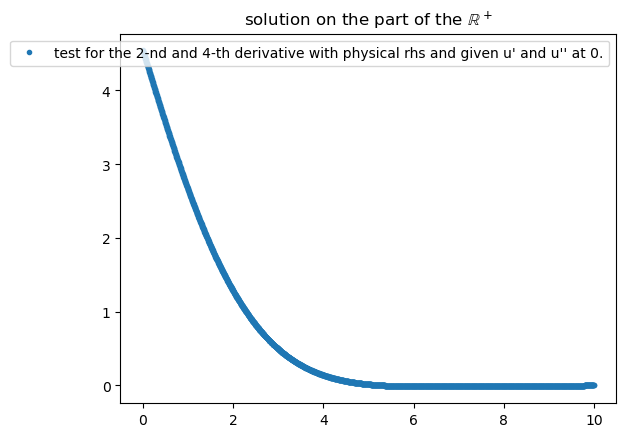

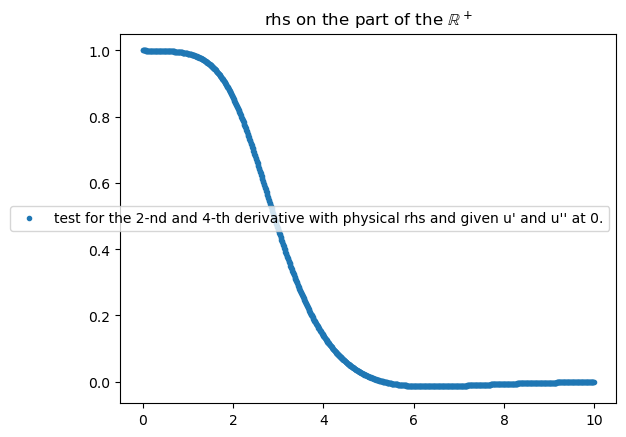

In [5]:
#testing a particular problem number
problem = all_problems[6]
problem.info()
problem.get_name()
solver.set_problem(problem)
c = solver.solve_problem()
plot_all(c, problem)

In [ ]:
#testing all problems
for problem in all_problems:
    print(problem.info())
    print(problem.get_name())
    solver.set_problem(problem)
    c = solver.solve_problem()
    plot_all(c, problem)
print("done.")